In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy.linalg as LA

In [100]:
#problem setup
B_pre = np.array(([-1.835, 0.739, 1.096],[0.739, -1.584, 0.845],[1.096, 0.845, -1.941]))
B_on = np.array(([-1.835, 0, 1.096],[0, -1.584, 0.845],[1.096, 0.845, -1.941]))

M = np.array([1,1,1])*0.5
D = np.array([1,1,1])*0.05

pG = np.array([66.91, 16.73, 40.14])/100    #100 is the p.u. base

V = np.array([1,1,1])   #bus voltage magnitudes

t = np.arange(0,10,0.001) #time vector

w0 = 2*np.pi*60
x0 = np.array([0,w0,-46.63*np.pi/180,w0,-8.73*np.pi/180,w0])

#w0 = 2*np.pi*0
#x0 = np.array([0,w0,-46.63*np.pi/180,w0,-8.73*np.pi/180,w0])

In [101]:
def three_bus(x,t,B,p):
    
    x_dot = np.empty((6,))
    
    x_dot[0] = x[1]
    x_dot[1] = (p[0] + -D[0]*x[1] - V[0]*( V[1]*B[0,1]*np.sin(x[0] - x[2]) + V[2]*B[0,2]*np.sin(x[0] - x[4]) ))/M[0]
    
    x_dot[2] = x[3]
    x_dot[3] = (p[1] + -D[1]*x[3] - V[1]*( V[0]*B[1,0]*np.sin(x[2] - x[0]) + V[2]*B[1,2]*np.sin(x[2] - x[4]) ))/M[1]
    
    x_dot[4] = x[5]
    x_dot[5] = (p[2] + -D[2]*x[5] - V[2]*( V[0]*B[2,0]*np.sin(x[4] - x[0]) + V[1]*B[2,1]*np.sin(x[4] - x[2]) ))/M[2]
    
    return x_dot


In [76]:
test1 = V[1]*B_pre[0,1]*np.sin(x0[0] - x0[2]) +  V[2]*B_pre[0,2]*np.sin(x0[0] - x0[4])
print(test1)

test2 =  V[1]*( V[0]*B_pre[1,0]*np.sin(x0[2] - x0[0]) + V[2]*B_pre[1,2]*np.sin(x0[2] - x0[4]) )
print(test2)

test3 = V[2]*( V[0]*B_pre[2,0]*np.sin(x0[4] - x0[0]) + V[1]*B_pre[2,1]*np.sin(x0[4] - x0[2]) )
print(test3)

0.7035535670785374
-1.056275463611184
0.35272189653264663


In [77]:
test1+test2+test3

1.1102230246251565e-16

In [102]:
66.91-16.73

50.17999999999999

In [98]:
x_ = odeint(three_bus, x0, t, args=(B_pre,pG))

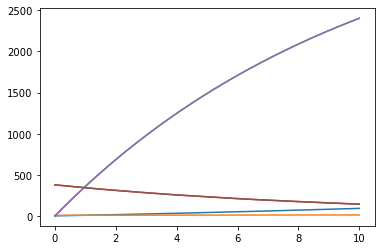

In [99]:
#plot

plt.plot(t,x_)
plt.show()